# Импорт библиотек

In [1]:
from keras.layers import Dense
from keras.models import Sequential
from keras.datasets import mnist
from keras import utils
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

2025-11-05 20:52:06.298834: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-05 20:52:06.349974: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-05 20:52:07.488720: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Задание

Используя документацию библиотеки, прочитайте о назначении каждого модуля. Зафиксируйте эти сведения в дополнительной текстовой ячейке.

# Ответ
## Назначение импортируемых модулей и сущностей

- `Dense` - полносвязный слой нейронной сети, где каждый нейрон соединен со всеми нейронами предыдущего слоя
- `Sequential` - модель нейронной сети с последовательным соединением слоев
- `mnist` - набор данных рукописных цифр 0-9 для обучения и тестирования
- `utils` - утилиты Keras, включая функции для преобразования данных
- `numpy` - библиотека для работы с многомерными массивами и математическими операциями
- `matplotlib.pyplot` - библиотека для построения графиков и визуализации данных
- `%matplotlib inline` - волшебная команда jupyter notebook для отображения графиков внутри ячеек

# Инициализация наборов данных

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Изменение форматов  данных

In [3]:
X_train = X_train.reshape(60000, 784) 
X_test = X_test.reshape(10000, 784)

X_train = X_train.astype('float32') 
X_test = X_test.astype('float32') 
X_train /= 255 
X_test /= 255

# Задание

Используя дополнительные инструкции, определите исходный формат данных. Попытайтесь определить какие преобразования и для чего производятся в результате выполнения нижеприведённого кода.

# Ответ
## Анализ преобразований данных

- **Исходный формат**: Изображения MNIST имеют размер 28x28 пикселей (двумерные массивы)
- **reshape(60000, 784)**: Преобразование двумерных изображений в одномерные векторы (28*28=784) для подачи в полносвязную сеть
- **astype('float32')**: Преобразование типа данных из целых чисел в числа с плавающей точкой для математических операций
- **деление на 255**: Нормализация значений пикселей из диапазона [0, 255] в диапазон [0, 1] для улучшения обучения сети

# Пример выходных данных

In [4]:
n = 100 
print(y_train[n])

5


# Преобразуем метки в формат one hot encoding

In [5]:
Y_train = utils.to_categorical(y_train, 10) 
Y_test = utils.to_categorical(y_test, 10)

# Правильный ответ в формате one hot encoding

In [6]:
print(Y_train[n])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# Создаем нейронную сеть

In [7]:
model = Sequential()

# Добавляем уровни сети

In [8]:
model.add(Dense(784, input_dim=784, activation="relu"))
model.add(Dense(200, input_dim=784, activation="relu"))
model.add(Dense(10, activation="softmax"))


/home/alexcawl/VsCodeProjects/SUSU.PE/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1762357929.039779  169768 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1762357929.047022  169768 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Задание

Используя документацию, определите основные параметры метода add. Запишите полученные сведения в дополнительной текстовой ячейке. Опишите топологию создаваемой в программе нейронной сети и ее особенности (используемые функции активации, …).

# Ответ
## Параметры метода add

**Основные параметры Dense:**
- **Первый параметр** - количество нейронов в слое
- **input_dim** - размерность входных данных
- **activation** - функция активации

## Топология сети
- **Входной слой**: 784 нейрона (28x28 пикселей), функция активации ReLU
- **Скрытый слой**: 200 нейронов, функция активации ReLU
- **Выходной слой**: 10 нейронов (10 классов цифр), функция активации Softmax

## Особенности
- **ReLU** - линейная функция активации, возвращает max(0, x)
- **Softmax** - преобразует выходы в вероятности (сумма = 1)

# Компилируем сеть

In [9]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]) 
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 774,450 (2.95 MB)

 Trainable params: 774,450 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

None


# Задание

Используя справочный материал, поясните значение каждого параметра метода compile

# Ответ
## Параметры метода compile

- **loss** - функция потерь, которую минимизирует сеть. `categorical_crossentropy` - для многоклассовой классификации
- **optimizer** - алгоритм оптимизации. `adam` - адаптивный метод оптимизации
- **metrics** - метрики для оценки качества модели. `accuracy` - точность классификации

# Обучаем нейронную сеть

* Для обучения нейронной сети будем использовать обучающую выборку X_train и правильные ответы для нее Y_train.
* Параметр bath_size определяет количество образцов, которые будут одновременно использованы для обучения сети. Этот параметр оказывает влияние на алгоритм обучения.
* Параметр epochs отвечает за число эпох обучения.
* Параметр validation_split отвечает за долю первоначальных исходных данных, которые пойдут для тестирования обученной сети. Остальная часть исходных данных пойдет для обучения сети.
* Параметр verbose отвечает за настройку алгоритма обучения сети.

In [10]:
history = model.fit(X_train, Y_train, batch_size=200, epochs=25, validation_split=0.2, verbose=2)

Epoch 1/25
240/240 - 2s - 10ms/step - accuracy: 0.9233 - loss: 0.2671 - val_accuracy: 0.9625 - val_loss: 0.1341
Epoch 2/25
240/240 - 2s - 7ms/step - accuracy: 0.9713 - loss: 0.0948 - val_accuracy: 0.9707 - val_loss: 0.1001
Epoch 3/25
240/240 - 2s - 7ms/step - accuracy: 0.9834 - loss: 0.0553 - val_accuracy: 0.9663 - val_loss: 0.1024
Epoch 4/25
240/240 - 2s - 7ms/step - accuracy: 0.9883 - loss: 0.0383 - val_accuracy: 0.9785 - val_loss: 0.0736
Epoch 5/25
240/240 - 2s - 7ms/step - accuracy: 0.9918 - loss: 0.0250 - val_accuracy: 0.9771 - val_loss: 0.0819
Epoch 6/25
240/240 - 2s - 7ms/step - accuracy: 0.9938 - loss: 0.0200 - val_accuracy: 0.9777 - val_loss: 0.0796
Epoch 7/25
240/240 - 2s - 7ms/step - accuracy: 0.9956 - loss: 0.0144 - val_accuracy: 0.9763 - val_loss: 0.0894
Epoch 8/25
240/240 - 2s - 7ms/step - accuracy: 0.9964 - loss: 0.0121 - val_accuracy: 0.9768 - val_loss: 0.0890
Epoch 9/25
240/240 - 2s - 7ms/step - accuracy: 0.9954 - loss: 0.0140 - val_accuracy: 0.9803 - val_loss: 0.0815


# Качество работы сети на тестовых данных

In [11]:
scores = model.evaluate(X_test, Y_test, verbose=0) 
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 98.08%


In [12]:
from keras.callbacks import History
history_dict: History = history.history

# Задание

Используя справочный материал, изучите атрибуты объекта History. Приведите их краткое описание.

# Ответ

## Атрибуты объекта History

- **history** - словарь, содержащий значения метрик на каждой эпохе
- **epoch** - список номеров эпох
- **params** - параметры обучения

## Ключи в history.history
- **'loss'** - значения функции потерь на обучающей выборке
- **'accuracy'** - точность на обучающей выборке
- **'val_loss'** - значения функции потерь на валидационной выборке
- **'val_accuracy'** - точность на валидационной выборке

# Для построения графика качества обучения используется библиотека matplotlib

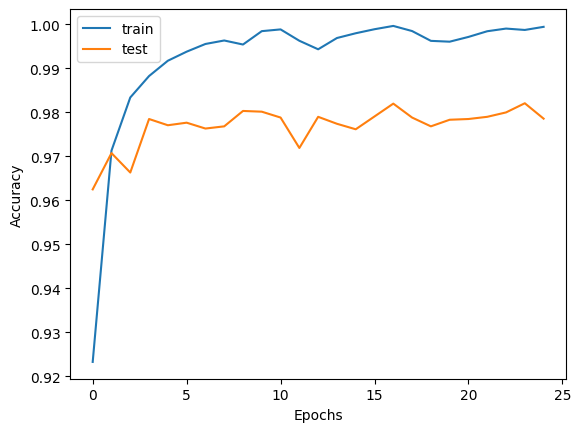

In [13]:

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.show()

# Теперь можно распознать рукописную цифру из набора данных, используя обученную сеть:

In [14]:
n_rec = 488

In [15]:
x = X_test[n_rec] 
x = np.expand_dims(x, axis=0)

In [16]:
prediction = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [17]:
print(prediction)

[[1.5709696e-14 9.8142492e-17 1.4333999e-17 1.6146887e-13 6.4797234e-10
  2.9539073e-17 2.1830834e-16 2.0881008e-09 1.7131651e-13 1.0000000e+00]]


In [18]:
prediction = np.argmax(prediction) 
print(prediction)

9


In [19]:
print(y_test[n_rec])

9


# Используя графический редактор paint создайте изображение рукописной цифры

Используйте базовый инструмент «Карандаш». Размер изображения должен быть 28 на 28 пикселей или близкий к этому, поскольку при преобразовании изображение сильно искажается. Сохраните изображение в формате jpeg.


# Импорт библиотек для обработки изображения.  Загрузка и обработка изображения с google-диска

In [20]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("data/1.jpg", cv2.IMREAD_UNCHANGED)
resolution = (28, 28)
img = cv2.resize(img, resolution)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_data = (255.0 - img.reshape(-1)) / 255

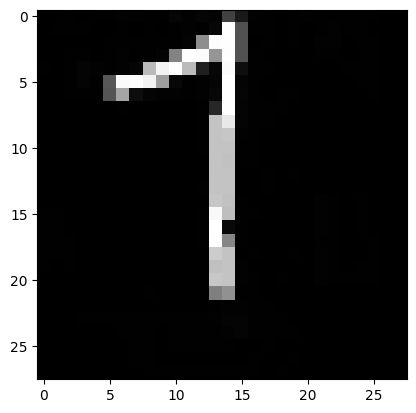

In [21]:
plt.imshow(img_data.reshape(28,28), cmap='gray')

# Задание

Поясните, какого рода преобразования изображения были произведены, для чего

# Ответ

## Преобразования изображения

1. **cv2.resize(img, (28, 28))** - изменение размера изображения до 28x28 пикселей (стандарт MNIST)
2. **cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)** - преобразование цветного изображения в оттенки серого
3. **(255.0-img.reshape(-1))/255** - инверсия цветов (черный становится белым) и нормализация в диапазон [0,1]
4. **reshape(-1)** - преобразование в одномерный вектор для подачи в сеть

## Цель преобразований

Привести изображение к тому же формату, на котором обучалась модель (28x28, оттенки серого, нормализованные значения)

In [22]:
x=np.expand_dims(img_data,axis=0)

# Используя обученную сеть, пробуем распознать вновь созданное изображение

In [23]:
prediction = model.predict(x)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[3.99351524e-11 9.99538064e-01 1.78053044e-04 1.60551470e-04
  6.91656368e-12 4.73881627e-08 1.12619191e-05 1.34306151e-06
  1.10721936e-04 4.22049928e-13]]


# Оцените результат

In [24]:
prediction = np.argmax(prediction)
print(prediction)

1
